In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from src.logger import logging
import os
import time
import mlflow

In [2]:
df = pd.read_csv(r'D:\Resume-Screening-Matching-System\data_upload_S3\data\cleaned_dataset.csv')
df.head()

,Role,Resume
0,E-commerce Specialist,Here's a professional resume for Jason Jones:\...
1,Game Developer,Here's a professional resume for Ann Marshall:...
2,Human Resources Specialist,Here's a professional resume for Patrick Mccla...
3,E-commerce Specialist,Here's a professional resume for Patricia Gray...
4,E-commerce Specialist,Here's a professional resume for Amanda Gross:...


In [3]:
df.describe()

,Role,Resume
count,10174,10174
unique,31,10174
top,Software Engineer,Here's a professional resume for Jason Jones:\...
freq,853,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10174 entries, 0 to 10173
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Role    10174 non-null  str  
 1   Resume  10174 non-null  str  
dtypes: str(2)
memory usage: 159.1 KB


In [5]:
df['Role'].value_counts()

Role
Software Engineer               853
Data Scientist                  825
Product Manager                 761
Data Engineer                   754
Data Analyst                    512
UI Engineer                     507
Human Resources Specialist      274
E-commerce Specialist           268
DevOps Engineer                 266
Machine Learning Engineer       265
Digital Marketing Specialist    260
Robotics Engineer               257
Cloud Architect                 254
QA Engineer                     251
Blockchain Developer            251
UI Designer                     248
Mobile App Developer            247
Full Stack Developer            246
Database Administrator          243
Cybersecurity Analyst           243
Cloud Engineer                  240
Game Developer                  239
System Administrator            239
AI Researcher                   238
Content Writer                  238
AR/VR Developer                 237
UX Designer                     227
Business Analyst       

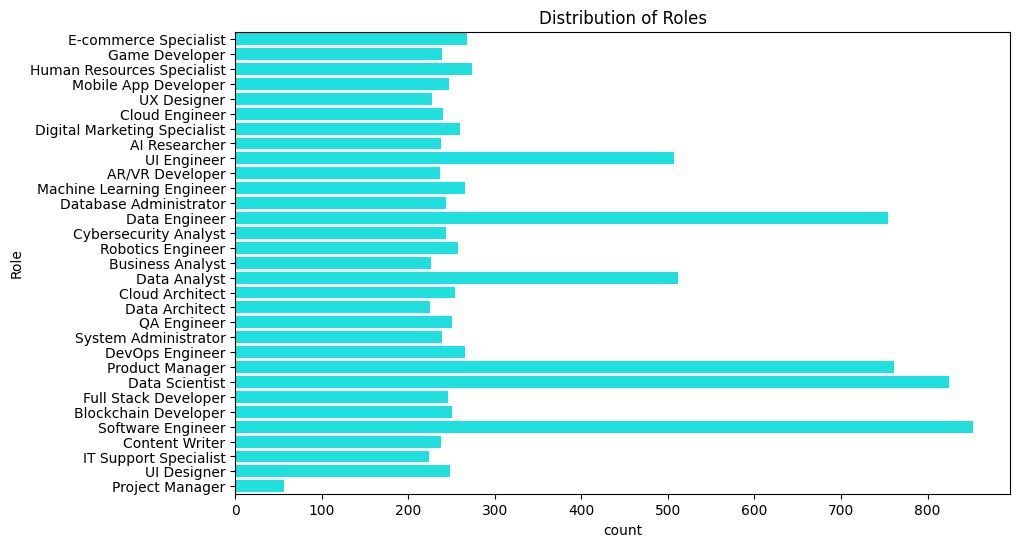

In [6]:
plt.figure(figsize=(10,6))
sns.countplot(df['Role'],color='cyan')
plt.title('Distribution of Roles')
plt.show()

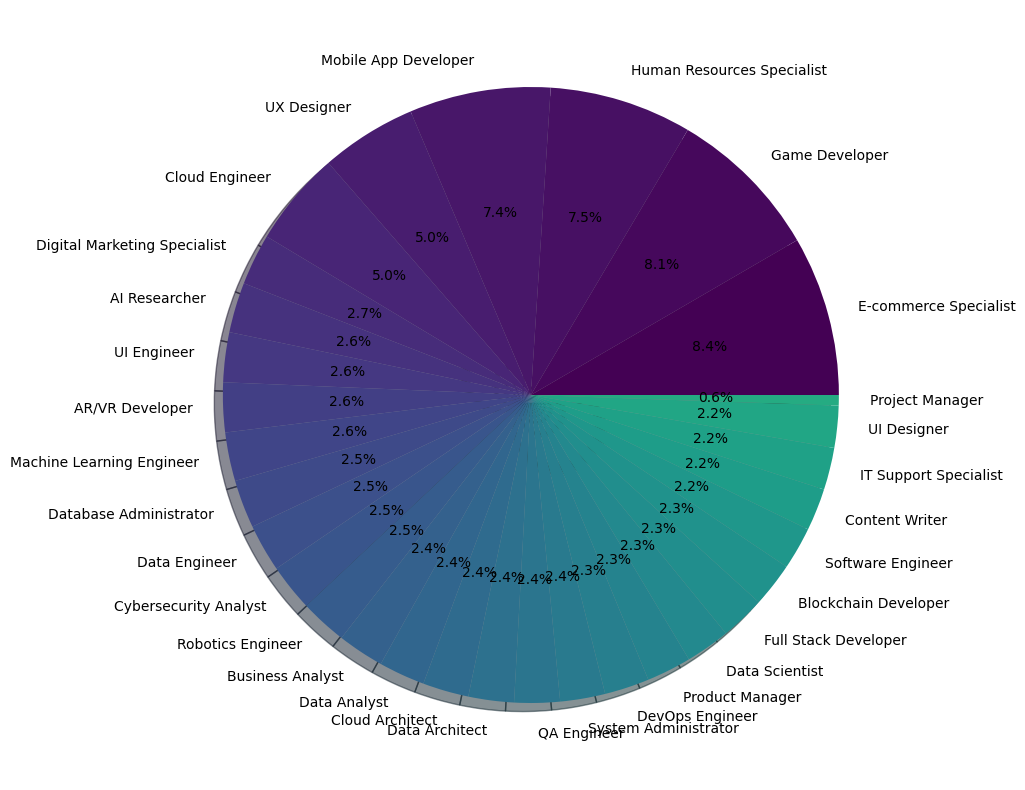

In [7]:
counts = df['Role'].value_counts()
labels = df['Role'].unique()
plt.figure(figsize=(15,10))

plt.pie(counts,labels=labels,autopct='%1.1f%%',shadow=True, colors=plt.cm.viridis(np.linspace(0, 1)))
plt.show()

Preprocessing Data:

In [8]:
def clean_text(text):
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove URLs (linkedin, github, websites)
    text = re.sub(r'http\S+|www\.\S+|linkedin\.com/\S+|github\.com/\S+', ' ', text)

    # Remove phone numbers
    text = re.sub(
        r'(\+\d{1,3}[-.\s]?)?(\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4})',
        ' ',
        text
    )

    # Remove markdown links
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)

    # Remove bullet symbols
    text = re.sub(r'[•▪◦●■♦★]', ' ', text)

    # Remove asterisks used as bullets
    text = re.sub(r'\*', ' ', text)

    # Keep only letters, numbers, +, #, /, . and spaces
    text = re.sub(r'[^a-zA-Z0-9+#/. ]', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    

    return text

def lemmatization(text):
    """Lemmatize the text."""
    lemmatizer = WordNetLemmatizer()
    text = text.split()
    text = [lemmatizer.lemmatize(word) for word in text]
    return " ".join(text)

def remove_stop_words(text):
    """Remove stop words from the text."""
    stop_words = set(stopwords.words("english"))
    text = [word for word in str(text).split() if word not in stop_words]
    return " ".join(text)

def normalize_text(text):
    """Normalize the text by applying all preprocessing steps."""
    text = clean_text(text)
    text = lemmatization(text)
    text = remove_stop_words(text)
    return text

In [9]:
text = """  $$ my gmail is abc@gmail.com ,
and mobile number is (123) 456-7890
and my linkedin is https://www.linkedin.com/in/abc
and github is https://github.com/abc (2002)"""

normalize_text(text)

'gmail mobile number linkedin github 2002'

In [10]:
df['Resume'] = df['Resume'].apply(lambda x: normalize_text(x))

In [11]:
df['Resume'][0]

'professional resume jason jones jason jones e commerce specialist contact information email phone linkedin summary result driven e commerce specialist 5+ year experience inventory management seo online advertising analytics. proven track record increasing online sale improving website traffic optimizing inventory levels. skilled analyzing complex data set identifying trend making data driven decisions. passionate staying date latest e commerce trend technologies. professional experience e commerce specialist xyz corporation 2018 present managed inventory level across multiple channel resulting 25 reduction stockouts 15 reduction overstocking developed implemented seo strategy increased website traffic 30 improved search engine ranking 20 created executed online advertising campaign generated 50 increase sale 20 increase conversion rate analyzed website analytics identify trend optimize user experience improve customer engagement collaborated cross functional team launch new product li

Target Column into Categorical values

In [12]:
label = LabelEncoder()
df['Role'] = label.fit_transform(df['Role'])
df.head()

,Role,Resume
0,15,professional resume jason jones jason jones e ...
1,17,professional resume ann marshall ann marshall ...
2,18,professional resume patrick mcclain patrick mc...
3,15,professional resume patricia gray patricia gra...
4,15,professional resume amanda gross amanda gross ...


Train Test Split:

In [65]:
X_train, X_test, y_train, y_test = train_test_split(df['Resume'], df['Role'], test_size=0.2, random_state=42)

In [66]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8139,), (2035,), (8139,), (2035,))

Vectorizer

In [67]:
vectorizer = TfidfVectorizer(
    max_features=20,
    ngram_range=(1,2)
)
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
import dagshub

mlflow.set_tracking_uri('')
dagshub.init(repo_owner='mdzaid382', repo_name='', mlflow=True)

mlflow.set_experiment("Logistic Regression Baseline")

Model Training and classification report

In [ ]:
logging.info("Starting MLflow run...")

with mlflow.start_run():
    start_time = time.time()
    
    try:
        logging.info("Logging preprocessing parameters...")
        mlflow.log_param("vectorizer", "TF-IDF")
        mlflow.log_param("num_features", 100)
        mlflow.log_param("test_size", 0.25)

        logging.info("Initializing Logistic Regression model...")
        model = LogisticRegression()  # Increase max_iter to prevent non-convergence issues

        logging.info("Fitting the model...")
        model.fit(X_train, y_train)
        logging.info("Model training complete.")

        logging.info("Logging model parameters...")
        mlflow.log_param("model", "Logistic Regression")

        logging.info("Making predictions...")
        y_pred = model.predict(X_test)

        logging.info("Calculating evaluation metrics...")
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        logging.info("Logging evaluation metrics...")
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)

        logging.info("Saving and logging the model...")
        mlflow.sklearn.log_model(model, "model")

        # Log execution time
        end_time = time.time()
        logging.info(f"Model training and logging completed in {end_time - start_time:.2f} seconds.")

        # Print the results for verification
        logging.info(f"Accuracy: {accuracy}")
        logging.info(f"Precision: {precision}")
        logging.info(f"Recall: {recall}")
        logging.info(f"F1 Score: {f1}")

    except Exception as e:
        logging.error(f"An error occurred: {e}", exc_info=True)


Accuracy: 0.8801
Confusion Matrix:
[[ 44   0   0   1   0   0   0   0   0   0   0   1   0   1   0   0   0   0
    0   0   0   0   0   0   0   0   3   0   0   0   0]
 [  0  31   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  11
    1   0   0   3   0   0   0   0   0   0   0   0   0]
 [  0   0  39   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   6   0   0   0   0   0   0   0   0   0]
 [  0   0   0  39   0   0   0   0   6   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0  54   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   4  42   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   1   0   0   0   0  37   0   0   0   0   0   0   0   3   1   0   0
    0   0   0   0   1   1   0   0   0   0   0   0   0]
 [  0   0   1   0   0   0   0  32   0   0   0   0   3   0   2 

In [69]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.8940901830691731
Test Accuracy: 0.8800982800982801


In [70]:
text = """Ravi Kumar
Bangalore, India
Email : [ravi.k.dev@gmail.com](mailto:ravi.k.dev@gmail.com) | Mob: +91 98765 43210
LinkedIn: linkedin.com/in/ravikumar-dev
GitHub: github.com/ravikumar-dev

---

SUMMARY

Software Engineer with around 3.5+ years experience in building scalable backend systems and cloud-based applications. Worked on microservices architecture, API development and deployment automation. Interested in distributed systems and backend engineering.

---

SKILLS

Languages: Java, Python, JavaScript
Frameworks: Spring Boot, Node.js, Express
Cloud: AWS (EC2, S3, Lambda), Docker, Kubernetes
Database: MySQL, MongoDB
Tools: Git, Jenkins, Postman, Maven
Other: REST APIs, Microservices, CI/CD

---

WORK EXPERIENCE

Software Engineer
Tata Consultancy Services (TCS) — Bangalore
July 2021 – Present

* Designed and developed REST APIs using Spring Boot for banking applications
* Built microservices-based architecture for internal payment system
* Deployed applications on AWS EC2 using Docker containers
* Created CI/CD pipelines using Jenkins for automated deployment
* Worked with MySQL database optimization and query tuning
* Collaborated with frontend team for API integration

Junior Developer
Infosys Ltd — Pune
June 2019 – June 2021

* Developed backend services using Java and Spring framework
* Assisted in migrating monolithic application to microservices
* Wrote unit tests and improved code coverage
* Participated in Agile sprint development process
* Maintained legacy systems and bug fixing

---

EDUCATION

B.E. Computer Engineering
Pune University — 2019

---

CERTIFICATIONS

* AWS Certified Developer Associate (2022)
* Oracle Certified Java Programmer (2020)

---

PROJECTS

E-Commerce Backend System

* Built scalable backend using Spring Boot and MySQL
* Implemented authentication and order management module
* Integrated payment gateway APIs

---

DECLARATION

I hereby declare that the above information is true to the best of my knowledge.


"""

In [71]:
normalized_text = normalize_text(text)
print(normalized_text)

ravi kumar bangalore india email mob +91 98765 43210 linkedin github summary software engineer around 3.5+ year experience building scalable backend system cloud based applications. worked microservices architecture api development deployment automation. interested distributed system backend engineering. skill language java python javascript framework spring boot node.js express cloud aws ec2 s3 lambda docker kubernetes database mysql mongodb tool git jenkins postman maven rest apis microservices ci/cd work experience software engineer tata consultancy service tc bangalore july 2021 present designed developed rest apis using spring boot banking application built microservices based architecture internal payment system deployed application aws ec2 using docker container created ci/cd pipeline using jenkins automated deployment worked mysql database optimization query tuning collaborated frontend team api integration junior developer infosys ltd pune june 2019 june 2021 developed backend

In [72]:
vectorized_text  = vectorizer.transform([normalized_text])
predicted_role = model.predict(vectorized_text)
print("Predicted Role:", predicted_role[0])

Predicted Role: 26
